In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

### Non augmented

In [30]:
CLEANED_EXERCISE_PATH = "../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/"

In [31]:
excersise_files = sorted(glob.glob(os.path.join(CLEANED_EXERCISE_PATH, "*.csv")))
print(excersise_files)

['../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.0.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.1.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.10.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.100.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.101.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.102.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.103.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.104.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.105.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.106.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.107.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.108.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.109.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.11.csv', '../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_r

In [32]:
df = pd.read_csv(excersise_files[1])

In [33]:
tSec = (df['timestamp'] - df['timestamp'].iloc[0])/1000

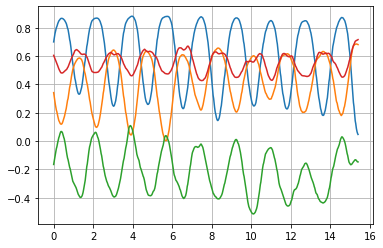

In [34]:
plt.plot(tSec, df['q0'], label='q0')
plt.plot(tSec, df['q1'], label='q1')
plt.plot(tSec, df['q2'], label='q2')
plt.plot(tSec, df['q3'], label='q3')
plt.grid()

### Augmentation

#### Time scaling

In [7]:
def scale_time(df, time_column, scale_range=(0.9, 1.1)):
    """Scales the time column of the DataFrame by a random factor within scale_range."""
    # Generate a random scaling factor from the specified range
    scale_factor = np.random.uniform(*scale_range)
    print(f"Scale factor: {scale_factor}")  # Print the scaling factor for verification

    # Create a new DataFrame to avoid modifying the original
    scaled_df = df.copy()
    # Update the values in the time column by multiplying them by the scaling factor
    scaled_df[time_column] = df[time_column] * scale_factor

    return scaled_df

In [8]:
df_aug = scale_time(df.copy(), 'timestamp')
tSec_aug = (df_aug['timestamp'] - df_aug['timestamp'].iloc[0])/1000

Scale factor: 0.9238132988237174


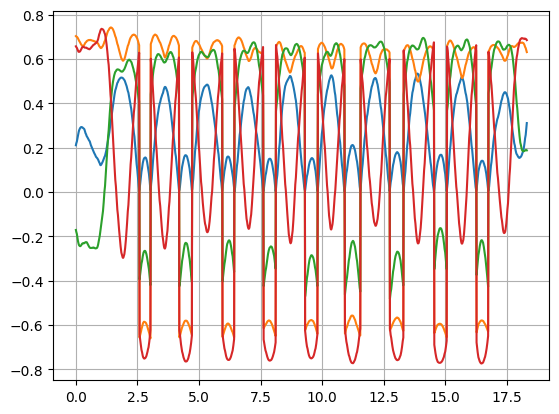

In [9]:
plt.plot(tSec_aug, df_aug['q0'], label='q0')
plt.plot(tSec_aug, df_aug['q1'], label='q1')
plt.plot(tSec_aug, df_aug['q2'], label='q2')
plt.plot(tSec_aug, df_aug['q3'], label='q3')

plt.grid()

#### Rotation points

In [10]:
def rotate_points(x, y, angle, center_x, center_y):
    """Rotate points by a given angle around a custom center."""
    angle_rad = np.radians(angle)
    cos_val, sin_val = np.cos(angle_rad), np.sin(angle_rad)
    x_centered, y_centered = x - center_x, y - center_y
    x_rotated = cos_val * x_centered - sin_val * y_centered + center_x
    y_rotated = sin_val * x_centered + cos_val * y_centered + center_y
    return x_rotated, y_rotated

def apply_rotation(df, columns, angle):
    """Apply rotation transformation to specified columns."""
    # Определение центра вращения (среднее значение столбцов)
    center_x, center_y = df[columns[0]].mean(), df[columns[1]].mean()
    
    # Применение функции вращения
    x_rotated, y_rotated = rotate_points(df[columns[0]], df[columns[1]], angle, center_x, center_y)
    df[columns[0]] = x_rotated
    df[columns[1]] = y_rotated
    return df

In [11]:
rotation_angle=90
df_aug = apply_rotation(df.copy(), ['q0', 'q1', 'q2', 'q3'], rotation_angle)
tSec_aug = (df_aug['timestamp'] - df_aug['timestamp'].iloc[0])/1000

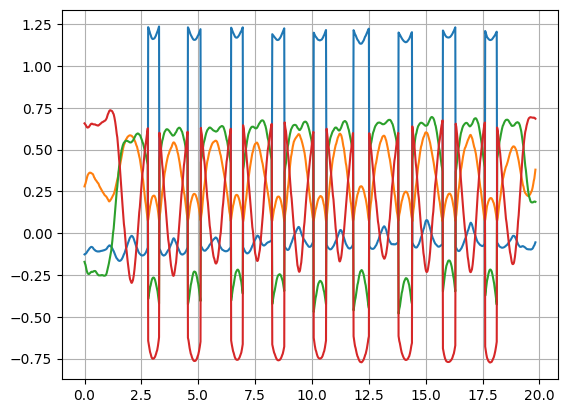

In [12]:
plt.plot(tSec_aug, df_aug['q0'], label='q0')
plt.plot(tSec_aug, df_aug['q1'], label='q1')
plt.plot(tSec_aug, df_aug['q2'], label='q2')
plt.plot(tSec_aug, df_aug['q3'], label='q3')

plt.grid()

#### Data scaling

In [13]:
def apply_scaling(df, columns, scale_factor):
    """Apply scaling transformation to specified columns."""
    df[columns] *= scale_factor
    return df

In [14]:
scale_var=0.1
scale_factor = 1 + np.random.uniform(-scale_var, scale_var)
augment_cols = df.columns[1:]
df_aug = apply_scaling(df.copy(), augment_cols, scale_factor)
tSec_aug = (df_aug['timestamp'] - df_aug['timestamp'].iloc[0])/1000

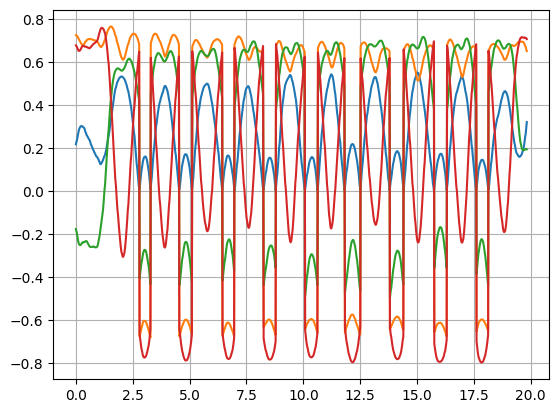

In [15]:
plt.plot(tSec_aug, df_aug['q0'], label='q0')
plt.plot(tSec_aug, df_aug['q1'], label='q1')
plt.plot(tSec_aug, df_aug['q2'], label='q2')
plt.plot(tSec_aug, df_aug['q3'], label='q3')

plt.grid()

#### Add noise

In [8]:
def add_noise(df, columns, noise_level):
    """Add Gaussian noise to specified columns."""
    noise = np.random.normal(loc=0.0, scale=noise_level, size=df[columns].shape)
    df[columns] += noise
    return df

In [35]:
noise_level=0.02
augment_cols = df.columns[1:]
df_aug = add_noise(df.copy(), augment_cols, noise_level)
tSec_aug = (df_aug['timestamp'] - df_aug['timestamp'].iloc[0])/1000

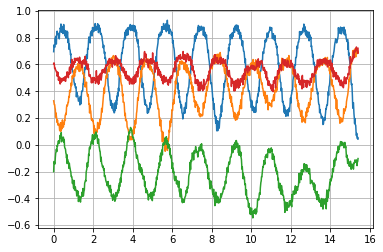

In [36]:
plt.plot(tSec_aug, df_aug['q0'], label='q0')
plt.plot(tSec_aug, df_aug['q1'], label='q1')
plt.plot(tSec_aug, df_aug['q2'], label='q2')
plt.plot(tSec_aug, df_aug['q3'], label='q3')

plt.grid()

## Augment exercises dataset

In [37]:
for i, file_path in enumerate(excersise_files):
    csv_filename = os.path.basename(file_path)
    path = os.path.dirname(file_path)

    df = pd.read_csv(file_path)
    
    # prepare augmented filename
    _, file = os.path.split(csv_filename)
    res = file.split('.')    
    aug_file_name = res[0] + '.' + 'aug_' + res[1] + '.' + res[2]
    full_aug_name = os.path.join(path, aug_file_name)
    
    # augment data from input file
    df_aug = add_noise(df.copy(), augment_cols, noise_level)    
    print(full_aug_name)
    # save augmented data
    df_aug.to_csv(full_aug_name, index=False)

../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_0.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_1.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_10.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_100.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_101.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_102.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_103.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_104.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_105.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_106.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_107.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_108.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_109.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_11.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_r

../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_43.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_44.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_45.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_46.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_47.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_48.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_49.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_5.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_50.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_51.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_52.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_53.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_54.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.aug_55.csv
../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/fron